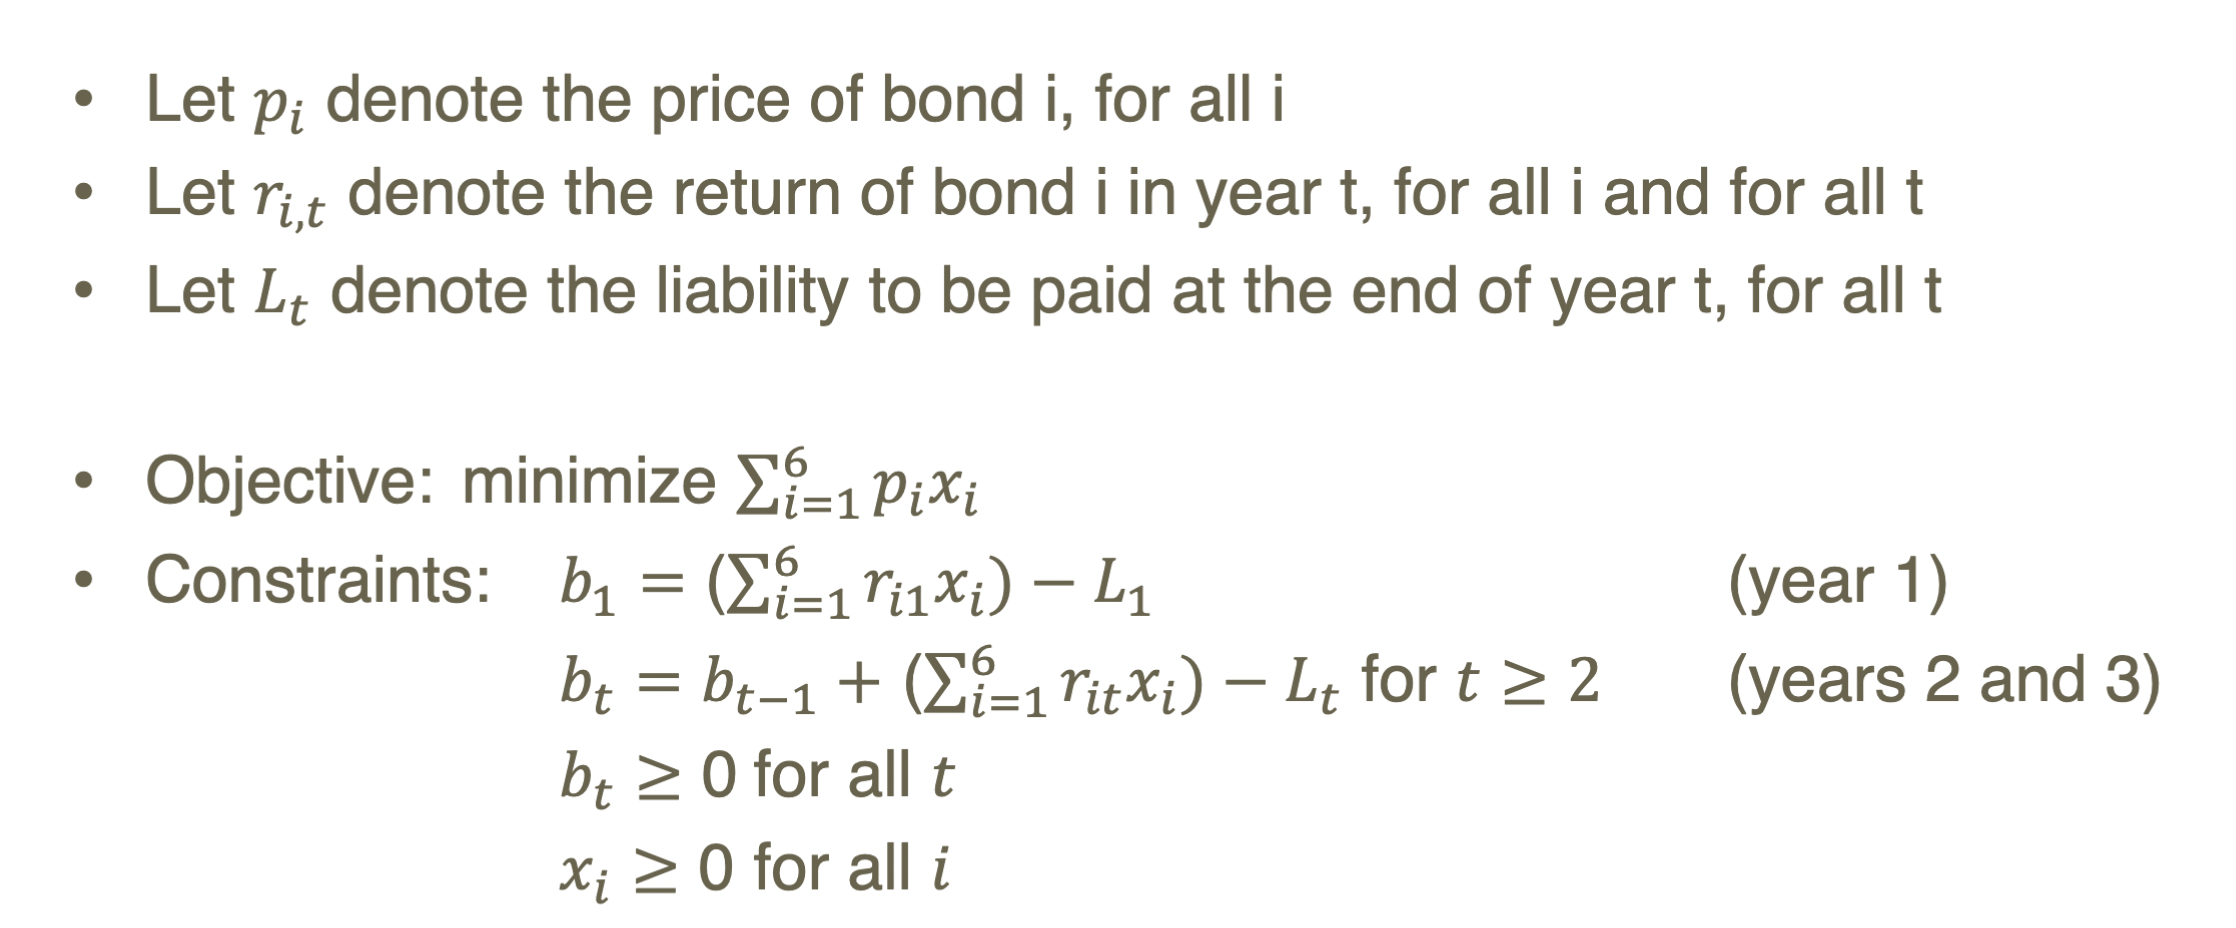

In [2]:
# Input data
Bonds = {'Bond 1', 'Bond 2', 'Bond 3', 'Bond 4', 'Bond 5', 'Bond 6' }
Years = range(1,4)       # {1,2,3}  This needs to be an ordered set!

Return = {
    ('Bond 1', 1): 10,	('Bond 1', 2): 10,	('Bond 1', 3): 110,
    ('Bond 2', 1): 7,	('Bond 2', 2): 7,	('Bond 2', 3): 107,
    ('Bond 3', 1): 8,	('Bond 3', 2): 8,	('Bond 3', 3): 108,
    ('Bond 4', 1): 6,	('Bond 4', 2): 106,	
    ('Bond 5', 1): 7,	('Bond 5', 2): 107,	
    ('Bond 6', 1): 105
}

Price = {'Bond 1' : 109, 'Bond 2' : 94.8, 'Bond 3' : 99.5, 'Bond 4' : 93.1, 'Bond 5' : 97.2, 'Bond 6' : 92.9 }

Liability = { 1: 100, 2: 800, 3: 1200 }

In [3]:
from docplex.mp.model import Model
mdl = Model()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [4]:
# variables
amount = mdl.continuous_var_dict(Bonds, lb=0, name="amount")
balance = mdl.continuous_var_dict(Years, lb=0, name="balance at end of year")

In [5]:
# objective
mdl.minimize(mdl.sum(Price[i]*amount[i] for i in Bonds))

In [13]:
# cash flow balance constraints
for t in Years:
    Payoffs = mdl.sum(Return[(i,t)]*amount[i] for i in Bonds if (i,t) in Return)
    if t==1:
        mdl.add_constraint(balance[t] == Payoffs - Liability[t])
    else:
        mdl.add_constraint(balance[t] == 1.01*balance[t-1] + Payoffs - Liability[t])

In [15]:
mdl.solve()
mdl.print_solution()

objective: 1680.636
  "amount_Bond 2"=11.215
  "amount_Bond 4"=6.632
  "balance at end of year_1"=18.298


In [16]:
print(11.215*7 + 6.632*6)

118.297


In [17]:
for i in amount:
    print(amount[i].solution_value)

0
0
11.214953271028037
0
0
6.632211382086698
